In [2]:
import torch

print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA: True
GPU: NVIDIA GeForce GTX 1660 Ti


In [4]:
import sys
!{sys.executable} -m pip install ultralytics

  Using cached ultralytics-8.4.41-py3-none-any.whl (1.2 MB)
  Using cached polars-1.36.1-py3-none-any.whl (802 kB)
  Using cached scipy-1.13.1-cp39-cp39-win_amd64.whl (46.2 MB)
  Using cached matplotlib-3.9.4-cp39-cp39-win_amd64.whl (7.8 MB)
  Using cached ultralytics_thop-2.0.19-py3-none-any.whl (28 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [5]:
from ultralytics import YOLO
print("Ultralytics imported ✅")

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\ahmed\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics imported ✅


In [7]:
DATA_PATH = r"D:\YOLO Model\vehicle dataset"  # 👈 عدّل المسار

In [9]:
import os
import shutil
import random
from pathlib import Path

BASE_PATH = r"D:\YOLO Model\vehicle dataset"  # 👈 المسار عندك

SRC_IMG = f"{BASE_PATH}\\train\\images"
SRC_LBL = f"{BASE_PATH}\\train\\labels"

DST = f"{BASE_PATH}\\dataset"

train_img = f"{DST}\\train\\images"
train_lbl = f"{DST}\\train\\labels"
val_img   = f"{DST}\\val\\images"
val_lbl   = f"{DST}\\val\\labels"

# إنشاء الفولدرات
for p in [train_img, train_lbl, val_img, val_lbl]:
    os.makedirs(p, exist_ok=True)

# قراءة الصور
images = list(Path(SRC_IMG).glob("*"))
random.shuffle(images)

# تقسيم 80/20
split = int(len(images) * 0.8)
train_files = images[:split]
val_files   = images[split:]

def copy_files(files, img_dst, lbl_dst):
    for img_path in files:
        shutil.copy(str(img_path), img_dst)

        lbl_path = Path(SRC_LBL) / (img_path.stem + ".txt")
        if lbl_path.exists():
            shutil.copy(str(lbl_path), lbl_dst)

print("Copying TRAIN...")
copy_files(train_files, train_img, train_lbl)

print("Copying VAL...")
copy_files(val_files, val_img, val_lbl)

print("Done ✅")

Copying TRAIN...
Copying VAL...
Done ✅


In [10]:
print("Train:", len(os.listdir(train_img)))
print("Val:", len(os.listdir(val_img)))

Train: 8804
Val: 2201


In [11]:
import yaml
import os

DATA_PATH = r"D:\YOLO Model\vehicle dataset\dataset"

data_yaml = {
    'path': DATA_PATH,
    'train': 'train/images',
    'val': 'val/images',
    'nc': 10,
    'names': [
        'Bus', 'Cyclist', 'Light Vehicle', 'Long Truck', 'Medium Truck',
        'Minibus Taxi', 'Motorcycle', 'Pedestrian',
        'Person with wheel barrow', 'Short Truck'
    ]
}

yaml_path = os.path.join(DATA_PATH, "data.yaml")

with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f)

print("data.yaml created ✅")
print("Path:", yaml_path)

data.yaml created ✅
Path: D:\YOLO Model\vehicle dataset\dataset\data.yaml


In [12]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data=fr"{DATA_PATH}\data.yaml",
    epochs=5,
    imgsz=640,
    batch=8,
    device=0,
    name="local_run"
)

Ultralytics 8.4.41  Python-3.9.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1660 Ti, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\YOLO Model\vehicle dataset\dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=local_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, o

val: New cache created: D:\YOLO Model\vehicle dataset\dataset\val\labels.cache
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000714, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Plotting labels to runs\detect\local_run\labels.jpg... 
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs\detect\local_run
Starting training for 5 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
        1/5      2.03G      1.161      1.889      1.071         12        640: 100% ━━━━━━━━━━━━ 1101/1101 3.4it/s 5:25<0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 138/138 3.5it/s 38.9s0.3ss
                   all       2201       8087      0.642      0.446      0.472      0.345

      Epoch    GPU_mem

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000019539840580>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,   

In [13]:
import shutil

shutil.copy(
    "runs/detect/local_run/weights/best.pt",
    "best.pt"
)

print("Model saved ✅")

Model saved ✅


In [14]:
model = YOLO("best.pt")

metrics = model.val(data=fr"{DATA_PATH}\data.yaml")

print("mAP50:", metrics.box.map50)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.41  Python-3.9.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1660 Ti, 6144MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.1 ms, read: 192.046.7 MB/s, size: 53.2 KB)
val: Scanning D:\YOLO Model\vehicle dataset\dataset\val\labels.cache... 2201 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2201/2201  0.0s
val: D:\YOLO Model\vehicle dataset\dataset\val\images\10205_png.rf.60df4a0cdae7e1662f14b44262934b85.jpg: 1 duplicate labels removed
val: D:\YOLO Model\vehicle dataset\dataset\val\images\10459_png.rf.4cef9757253f6e09adfd82c5402eb35a.jpg: 1 duplicate labels removed
val: D:\YOLO Model\vehicle dataset\dataset\val\images\11844_png.rf.931bf788bbc2096e88d073a520b0fcab.jpg: 1 duplicate labels removed
val: D:\YOLO Model\vehicle dataset\dataset\val\images\17302_png.rf.b196b8247d898db4a16c1881d1ebe989.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R     

In [15]:
results = model.predict(
    source=fr"{DATA_PATH}\val\images",
    save=True
)


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10004_png.rf.9a79b9c938d1622c413e261c884db0db.jpg: 640x640 1 Long Truck, 48.4ms
image 2/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10006_png.rf.52a7165b4ebe99d04f02fd244e2dcc99.jpg: 640x640 1 Pedestrian, 49.3ms
image 3/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10008_png.rf.ee900072a389a40ed8cddd559c62eb1f.jpg: 640x640 1 Cyclist, 1 Light Vehicle, 1 Motorcycle, 48.1ms
image 4

image 49/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10211_png.rf.6c4d6396d5f5812c2d3aecc40d10c72f.jpg: 640x640 2 Light Vehicles, 5 Minibus Taxis, 26.3ms
image 50/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10213_png.rf.4f1a9ecf968c574cb7a9097c27c14097.jpg: 640x640 1 Bus, 1 Light Vehicle, 1 Minibus Taxi, 25.3ms
image 51/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10214_png.rf.a8ba7f74da5d2b1a81c03a735fb32cb6.jpg: 640x640 1 Light Vehicle, 1 Minibus Taxi, 24.7ms
image 52/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10221_png.rf.1f3d8a68986f5c2d8755a6899b99edd5.jpg: 640x640 3 Minibus Taxis, 25.4ms
image 53/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10225_png.rf.d7f3b7dcddc2a0e3b053c4d7f6826f06.jpg: 640x640 3 Minibus Taxis, 24.2ms
image 54/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10230_png.rf.0b72e8440ea59413e65d06fd7719b0d3.jpg: 640x640 2 Light Vehicles, 4 Minibus Taxis, 24.9ms
image 55/2201 D:\YOLO Model\vehicle dataset\datas

image 98/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10445_png.rf.8d4ada7e922ac0ea00d9a336ea4507ad.jpg: 640x640 1 Light Vehicle, 1 Minibus Taxi, 2 Pedestrians, 26.0ms
image 99/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10447_png.rf.b364ad17ec05eaf890849912606d1a99.jpg: 640x640 1 Long Truck, 1 Minibus Taxi, 29.0ms
image 100/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10449_png.rf.e8dea569fa25100e76751dc903ca42c3.jpg: 640x640 1 Light Vehicle, 4 Minibus Taxis, 3 Pedestrians, 25.2ms
image 101/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10452_png.rf.15ebc816c9ebc07ed4f171860971ea8b.jpg: 640x640 2 Light Vehicles, 3 Minibus Taxis, 2 Pedestrians, 25.1ms
image 102/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10453_png.rf.7dedb83f8fc5941c14fa6df1aed908c2.jpg: 640x640 3 Light Vehicles, 2 Minibus Taxis, 3 Pedestrians, 24.7ms
image 103/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10459_png.rf.4cef9757253f6e09adfd82c5402eb35a.jpg: 640x640 2 

image 146/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10649_png.rf.9b85c87e4d7837c6d3899553f9682fa2.jpg: 640x640 1 Bus, 3 Light Vehicles, 24.0ms
image 147/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10655_png.rf.6afdfd03d860bee973f0fb7f2cd59280.jpg: 640x640 3 Light Vehicles, 3 Minibus Taxis, 2 Pedestrians, 26.4ms
image 148/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10674_png.rf.e01209a1a6a948f00004cf7af84206f0.jpg: 640x640 5 Light Vehicles, 2 Minibus Taxis, 21.9ms
image 149/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10676_png.rf.a231bc255708b5fcbdfa8598c5d5133a.jpg: 640x640 1 Bus, 4 Light Vehicles, 27.3ms
image 150/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10681_png.rf.363c98c76a742491cd728475ade15535.jpg: 640x640 5 Light Vehicles, 1 Minibus Taxi, 26.0ms
image 151/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10698_png.rf.ab91f70c0f30a816293a35cfb1972861.jpg: 640x640 1 Minibus Taxi, 1 Pedestrian, 24.6ms
image 152/2201 D:\YOL

image 197/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10956_png.rf.4cf655c26f02d3cb569b43b90ccd8157.jpg: 640x640 1 Light Vehicle, 1 Minibus Taxi, 1 Pedestrian, 23.4ms
image 198/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10961_png.rf.08f09ce24d34140aac02fe36a91c7018.jpg: 640x640 1 Bus, 27.4ms
image 199/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10968_png.rf.c483a9a58f03fb1ac20ddcee0349991c.jpg: 640x640 3 Light Vehicles, 1 Minibus Taxi, 1 Pedestrian, 23.7ms
image 200/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10969_png.rf.757aae0888d68db1db49aae4641cd13e.jpg: 640x640 1 Bus, 1 Light Vehicle, 1 Minibus Taxi, 1 Pedestrian, 23.7ms
image 201/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10975_png.rf.e387ef41194b55808d9ae59bc1e1ff2e.jpg: 640x640 1 Pedestrian, 1 Short Truck, 23.9ms
image 202/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10979_png.rf.b3e1e0eefe66bc2932fe002131127078.jpg: 640x640 2 Light Vehicles, 1 Minibus Taxi, 23.2ms
i

...

image 2004/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20264_png.rf.bf2603ced8aded763572f3c5a3a861d7.jpg: 640x640 2 Minibus Taxis, 1 Pedestrian, 1 Short Truck, 24.7ms
image 2005/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20272_png.rf.189548c4a52cbb2405756e01bd4c17e7.jpg: 640x640 1 Light Vehicle, 2 Long Trucks, 1 Minibus Taxi, 1 Pedestrian, 25.6ms
image 2006/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20273_png.rf.6cfde823d9c5f97416ae0c470cd826b0.jpg: 640x640 1 Light Vehicle, 1 Long Truck, 1 Minibus Taxi, 24.4ms
image 2007/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20274_png.rf.14d9abb95212995b3c0a7035146c30f7.jpg: 640x640 3 Light Vehicles, 2 Minibus Taxis, 26.8ms
image 2008/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20276_png.rf.db12b6f076efbee0a787141173e57517.jpg: 640x640 2 Light Vehicles, 1 Minibus Taxi, 1 Short Truck, 24.6ms
image 2009/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20278_png.rf.04dd434a3532a09986ec8fbf86aa

image 2053/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20478_png.rf.e4d5ef06ea389b89d319a1d82cc98c32.jpg: 640x640 3 Light Vehicles, 2 Minibus Taxis, 3 Pedestrians, 1 Short Truck, 25.7ms
image 2054/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20479_png.rf.1889461acd7882d7dd6cc1840d7df543.jpg: 640x640 1 Bus, 2 Light Vehicles, 3 Pedestrians, 22.4ms
image 2055/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20482_png.rf.fcc011e1ff5d6cff659a737e66bc1b1c.jpg: 640x640 1 Light Vehicle, 1 Long Truck, 1 Pedestrian, 21.7ms
image 2056/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20492_png.rf.945004a1c322020d811f217b7c47115d.jpg: 640x640 4 Light Vehicles, 1 Pedestrian, 23.2ms
image 2057/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20497_png.rf.ea1879ee6db64276fcf293aa75203e2f.jpg: 640x640 2 Light Vehicles, 1 Long Truck, 3 Pedestrians, 23.1ms
image 2058/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20499_png.rf.35105470e0f9b911b50215ede809a04e.jpg: 

image 2100/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20677_png.rf.8c503d70a028188e456dce084da65f35.jpg: 640x640 3 Light Vehicles, 1 Pedestrian, 1 Short Truck, 22.4ms
image 2101/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20679_png.rf.0e965b81e9d648cd48cdb7a9e66f0ecf.jpg: 640x640 1 Light Vehicle, 1 Long Truck, 22.6ms
image 2102/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20680_png.rf.ca86a8e560f7da7f2d496957785bfcc5.jpg: 640x640 1 Cyclist, 2 Light Vehicles, 1 Pedestrian, 1 Short Truck, 22.3ms
image 2103/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20682_png.rf.3e6395896ffab4faaff309c9da6c8d7f.jpg: 640x640 1 Bus, 4 Light Vehicles, 22.8ms
image 2104/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20684_png.rf.04beba2626d745d66da1a9e8a75ecc18.jpg: 640x640 2 Light Vehicles, 1 Long Truck, 1 Minibus Taxi, 24.7ms
image 2105/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20687_png.rf.4bbec4d7bf47187ce124ec41e9361a0a.jpg: 640x640 1 Long Truck

image 2148/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20919_png.rf.08f7dec7411a9e9f00a36f8ddce967dd.jpg: 640x640 1 Long Truck, 22.6ms
image 2149/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20926_png.rf.fec6ab39ae719fe78f26011c2e2d6ec3.jpg: 640x640 1 Minibus Taxi, 25.0ms
image 2150/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20932_png.rf.f24cc799d6b52e680a3064d1faeddc9e.jpg: 640x640 1 Light Vehicle, 1 Pedestrian, 1 Short Truck, 22.2ms
image 2151/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20935_png.rf.17abb482ce4f6960a2f05bfc4bfd0dec.jpg: 640x640 1 Medium Truck, 1 Short Truck, 22.5ms
image 2152/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20946_png.rf.5c1ee2b228c846b06ddf1b0fd07ad115.jpg: 640x640 1 Short Truck, 24.3ms
image 2153/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20960_png.rf.93c299dfc40b3131744380ca335423f2.jpg: 640x640 1 Short Truck, 23.6ms
image 2154/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20962_png.rf

image 2201/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\9998_png.rf.cb321d303bfeb259b1b1c88c44c35cf6.jpg: 640x640 3 Light Vehicles, 1 Long Truck, 1 Medium Truck, 1 Short Truck, 23.7ms
Speed: 13.2ms preprocess, 24.8ms inference, 4.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\ahmed\runs\detect\predict


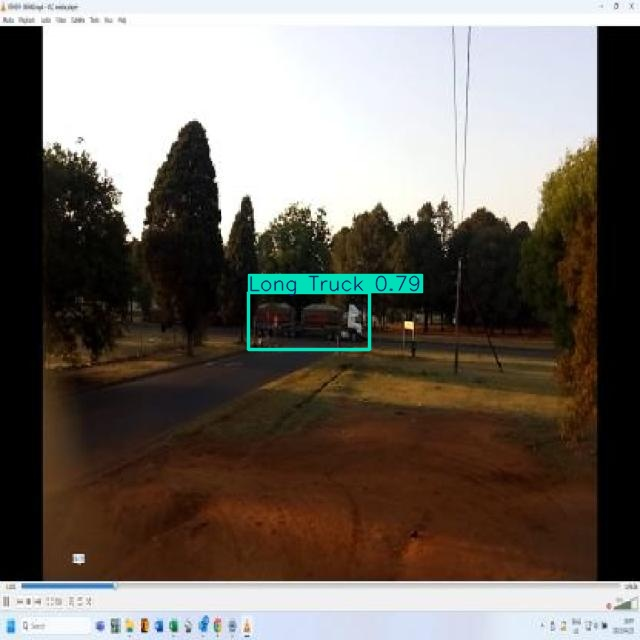

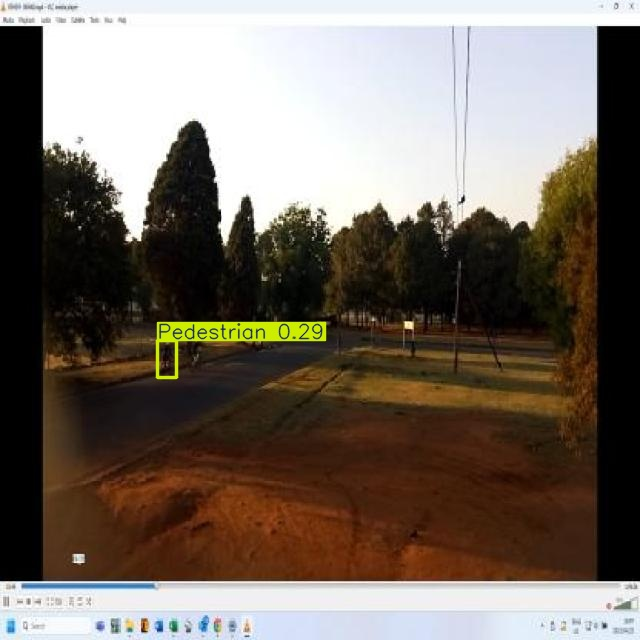

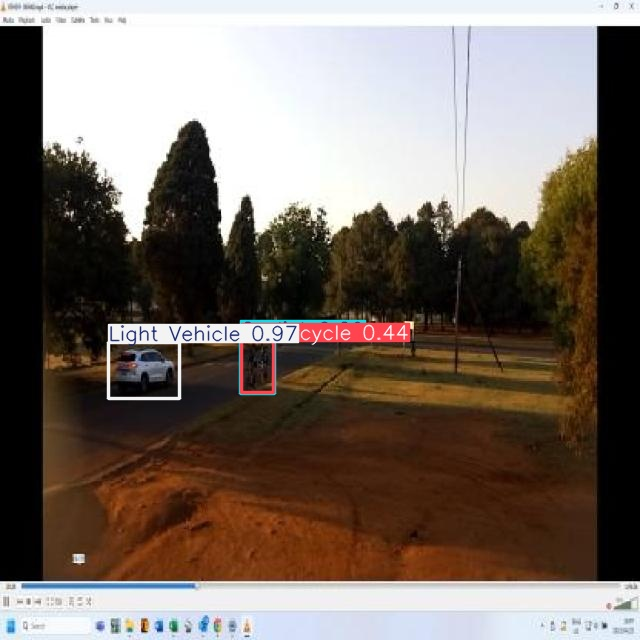

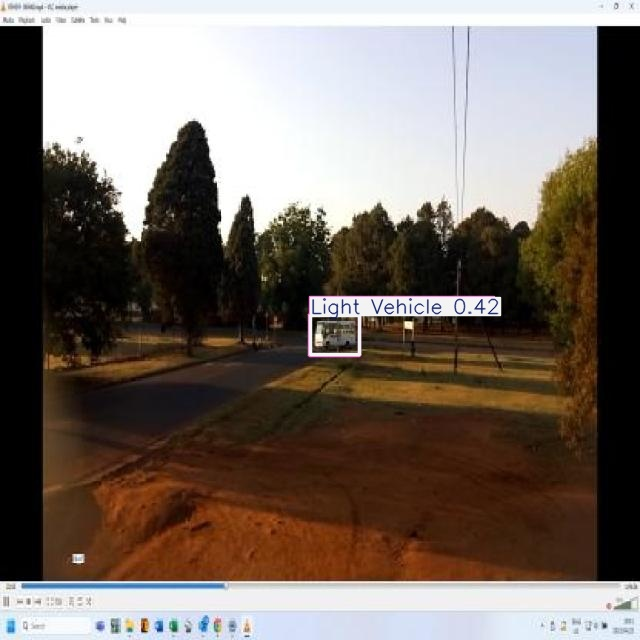

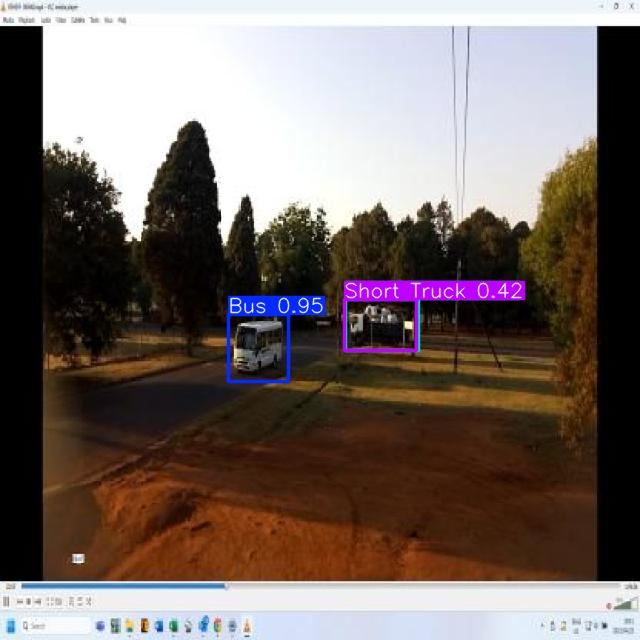

In [16]:
from IPython.display import Image, display
import os

path = "runs/detect/predict"

for img in os.listdir(path)[:5]:
    display(Image(filename=f"{path}/{img}"))

In [18]:
import pandas as pd

df = pd.read_csv("runs/detect/local_run/results.csv")

print(df.tail())

   epoch      time  train/box_loss  train/cls_loss  train/dfl_loss  \
0      1   366.186         1.16140         1.88863         1.07111   
1      2   690.490         1.03529         1.22280         1.03590   
2      3  1006.760         0.99141         1.05919         1.02663   
3      4  1462.120         0.95362         0.94195         1.01687   
4      5  1769.640         0.91860         0.87610         1.00104   

   metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
0               0.64215            0.44635           0.47219   
1               0.73098            0.50657           0.57112   
2               0.54790            0.65775           0.61890   
3               0.63086            0.61545           0.65419   
4               0.70891            0.63182           0.66380   

   metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
0              0.34453       0.95266       1.43908       1.00353  0.000238   
1              0.41569       0.91535  

In [19]:
from ultralytics import YOLO

model = YOLO("runs/detect/local_run/weights/last.pt")

model.train(
    data=fr"{DATA_PATH}\data.yaml",
    epochs=20,      # الهدف النهائي
    imgsz=640,
    batch=8,
    device=0,
    resume=True
)

WARNING model 'runs\detect\local_run\weights\last.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.41  Python-3.9.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1660 Ti, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\YOLO Model\vehicle dataset\dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=

optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000714, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Plotting labels to C:\Users\ahmed\runs\detect\train\labels.jpg... 
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to C:\Users\ahmed\runs\detect\train
Starting training for 20 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/20      2.03G     0.9045     0.8435     0.9937         12        640: 100% ━━━━━━━━━━━━ 1101/1101 3.6it/s 5:05<0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 138/138 3.8it/s 36.3s0.3s
                   all       2201       8087      0.737      0.615       0.66      0.489

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000019519851070>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,   

In [21]:
import shutil

shutil.copy(
    "runs/detect/local_run/weights/best.pt",
    "best.pt"
)

print("Model saved ✅")

Model saved ✅


In [22]:
shutil.copy(
    "runs/detect/local_run/weights/best.pt",
    r"D:\YOLO Model\best.pt"
)

'D:\\YOLO Model\\best.pt'

In [23]:
shutil.copy(
    "runs/detect/local_run/weights/last.pt",
    "last.pt"
)

'last.pt'

In [24]:
from ultralytics import YOLO

model = YOLO(r"D:\YOLO Model\best.pt")  # المسار اللي حفظت فيه

metrics = model.val(data=fr"{DATA_PATH}\data.yaml", device=0)

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.41  Python-3.9.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1660 Ti, 6144MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.20.1 ms, read: 131.259.8 MB/s, size: 55.2 KB)
val: Scanning D:\YOLO Model\vehicle dataset\dataset\val\labels.cache... 2201 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2201/2201 2.2Mit/s 0.0s
val: D:\YOLO Model\vehicle dataset\dataset\val\images\10205_png.rf.60df4a0cdae7e1662f14b44262934b85.jpg: 1 duplicate labels removed
val: D:\YOLO Model\vehicle dataset\dataset\val\images\10459_png.rf.4cef9757253f6e09adfd82c5402eb35a.jpg: 1 duplicate labels removed
val: D:\YOLO Model\vehicle dataset\dataset\val\images\11844_png.rf.931bf788bbc2096e88d073a520b0fcab.jpg: 1 duplicate labels removed
val: D:\YOLO Model\vehicle dataset\dataset\val\images\17302_png.rf.b196b8247d898db4a16c1881d1ebe989.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P        

In [25]:
results = model.predict(
    source=fr"{DATA_PATH}\val\images",
    save=True,
    conf=0.25,   # عدّلها لو حابب
    device=0
)


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10004_png.rf.9a79b9c938d1622c413e261c884db0db.jpg: 640x640 1 Long Truck, 48.1ms
image 2/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10006_png.rf.52a7165b4ebe99d04f02fd244e2dcc99.jpg: 640x640 1 Pedestrian, 59.7ms
image 3/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10008_png.rf.ee900072a389a40ed8cddd559c62eb1f.jpg: 640x640 1 Cyclist, 1 Light Vehicle, 1 Motorcycle, 58.4ms
image 4

image 49/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10211_png.rf.6c4d6396d5f5812c2d3aecc40d10c72f.jpg: 640x640 2 Light Vehicles, 5 Minibus Taxis, 24.3ms
image 50/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10213_png.rf.4f1a9ecf968c574cb7a9097c27c14097.jpg: 640x640 1 Bus, 1 Light Vehicle, 1 Minibus Taxi, 25.3ms
image 51/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10214_png.rf.a8ba7f74da5d2b1a81c03a735fb32cb6.jpg: 640x640 1 Light Vehicle, 1 Minibus Taxi, 22.8ms
image 52/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10221_png.rf.1f3d8a68986f5c2d8755a6899b99edd5.jpg: 640x640 3 Minibus Taxis, 25.4ms
image 53/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10225_png.rf.d7f3b7dcddc2a0e3b053c4d7f6826f06.jpg: 640x640 3 Minibus Taxis, 23.4ms
image 54/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10230_png.rf.0b72e8440ea59413e65d06fd7719b0d3.jpg: 640x640 2 Light Vehicles, 4 Minibus Taxis, 23.5ms
image 55/2201 D:\YOLO Model\vehicle dataset\datas

image 98/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10445_png.rf.8d4ada7e922ac0ea00d9a336ea4507ad.jpg: 640x640 1 Light Vehicle, 1 Minibus Taxi, 2 Pedestrians, 24.4ms
image 99/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10447_png.rf.b364ad17ec05eaf890849912606d1a99.jpg: 640x640 1 Long Truck, 1 Minibus Taxi, 23.7ms
image 100/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10449_png.rf.e8dea569fa25100e76751dc903ca42c3.jpg: 640x640 1 Light Vehicle, 4 Minibus Taxis, 3 Pedestrians, 22.7ms
image 101/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10452_png.rf.15ebc816c9ebc07ed4f171860971ea8b.jpg: 640x640 2 Light Vehicles, 3 Minibus Taxis, 2 Pedestrians, 24.2ms
image 102/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10453_png.rf.7dedb83f8fc5941c14fa6df1aed908c2.jpg: 640x640 3 Light Vehicles, 2 Minibus Taxis, 3 Pedestrians, 23.7ms
image 103/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10459_png.rf.4cef9757253f6e09adfd82c5402eb35a.jpg: 640x640 2 

image 146/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10649_png.rf.9b85c87e4d7837c6d3899553f9682fa2.jpg: 640x640 1 Bus, 3 Light Vehicles, 22.5ms
image 147/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10655_png.rf.6afdfd03d860bee973f0fb7f2cd59280.jpg: 640x640 3 Light Vehicles, 3 Minibus Taxis, 2 Pedestrians, 23.9ms
image 148/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10674_png.rf.e01209a1a6a948f00004cf7af84206f0.jpg: 640x640 5 Light Vehicles, 2 Minibus Taxis, 23.4ms
image 149/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10676_png.rf.a231bc255708b5fcbdfa8598c5d5133a.jpg: 640x640 1 Bus, 4 Light Vehicles, 24.0ms
image 150/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10681_png.rf.363c98c76a742491cd728475ade15535.jpg: 640x640 5 Light Vehicles, 1 Minibus Taxi, 24.7ms
image 151/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10698_png.rf.ab91f70c0f30a816293a35cfb1972861.jpg: 640x640 1 Minibus Taxi, 1 Pedestrian, 23.0ms
image 152/2201 D:\YOL

image 197/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10956_png.rf.4cf655c26f02d3cb569b43b90ccd8157.jpg: 640x640 1 Light Vehicle, 1 Minibus Taxi, 1 Pedestrian, 27.3ms
image 198/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10961_png.rf.08f09ce24d34140aac02fe36a91c7018.jpg: 640x640 1 Bus, 26.7ms
image 199/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10968_png.rf.c483a9a58f03fb1ac20ddcee0349991c.jpg: 640x640 3 Light Vehicles, 1 Minibus Taxi, 1 Pedestrian, 24.9ms
image 200/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10969_png.rf.757aae0888d68db1db49aae4641cd13e.jpg: 640x640 1 Bus, 1 Light Vehicle, 1 Minibus Taxi, 1 Pedestrian, 22.6ms
image 201/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10975_png.rf.e387ef41194b55808d9ae59bc1e1ff2e.jpg: 640x640 1 Pedestrian, 1 Short Truck, 24.6ms
image 202/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\10979_png.rf.b3e1e0eefe66bc2932fe002131127078.jpg: 640x640 2 Light Vehicles, 1 Minibus Taxi, 25.1ms
i

...

image 2004/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20264_png.rf.bf2603ced8aded763572f3c5a3a861d7.jpg: 640x640 2 Minibus Taxis, 1 Pedestrian, 1 Short Truck, 23.4ms
image 2005/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20272_png.rf.189548c4a52cbb2405756e01bd4c17e7.jpg: 640x640 1 Light Vehicle, 2 Long Trucks, 1 Minibus Taxi, 1 Pedestrian, 23.1ms
image 2006/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20273_png.rf.6cfde823d9c5f97416ae0c470cd826b0.jpg: 640x640 1 Light Vehicle, 1 Long Truck, 1 Minibus Taxi, 23.1ms
image 2007/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20274_png.rf.14d9abb95212995b3c0a7035146c30f7.jpg: 640x640 3 Light Vehicles, 2 Minibus Taxis, 23.2ms
image 2008/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20276_png.rf.db12b6f076efbee0a787141173e57517.jpg: 640x640 2 Light Vehicles, 1 Minibus Taxi, 1 Short Truck, 23.4ms
image 2009/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20278_png.rf.04dd434a3532a09986ec8fbf86aa

image 2053/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20478_png.rf.e4d5ef06ea389b89d319a1d82cc98c32.jpg: 640x640 3 Light Vehicles, 2 Minibus Taxis, 3 Pedestrians, 1 Short Truck, 43.7ms
image 2054/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20479_png.rf.1889461acd7882d7dd6cc1840d7df543.jpg: 640x640 1 Bus, 2 Light Vehicles, 3 Pedestrians, 37.6ms
image 2055/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20482_png.rf.fcc011e1ff5d6cff659a737e66bc1b1c.jpg: 640x640 1 Light Vehicle, 1 Long Truck, 1 Pedestrian, 26.2ms
image 2056/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20492_png.rf.945004a1c322020d811f217b7c47115d.jpg: 640x640 4 Light Vehicles, 1 Pedestrian, 24.7ms
image 2057/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20497_png.rf.ea1879ee6db64276fcf293aa75203e2f.jpg: 640x640 2 Light Vehicles, 1 Long Truck, 3 Pedestrians, 22.9ms
image 2058/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20499_png.rf.35105470e0f9b911b50215ede809a04e.jpg: 

image 2100/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20677_png.rf.8c503d70a028188e456dce084da65f35.jpg: 640x640 3 Light Vehicles, 1 Pedestrian, 1 Short Truck, 22.9ms
image 2101/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20679_png.rf.0e965b81e9d648cd48cdb7a9e66f0ecf.jpg: 640x640 1 Light Vehicle, 1 Long Truck, 23.5ms
image 2102/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20680_png.rf.ca86a8e560f7da7f2d496957785bfcc5.jpg: 640x640 1 Cyclist, 2 Light Vehicles, 1 Pedestrian, 1 Short Truck, 25.4ms
image 2103/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20682_png.rf.3e6395896ffab4faaff309c9da6c8d7f.jpg: 640x640 1 Bus, 4 Light Vehicles, 38.9ms
image 2104/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20684_png.rf.04beba2626d745d66da1a9e8a75ecc18.jpg: 640x640 2 Light Vehicles, 1 Long Truck, 1 Minibus Taxi, 34.1ms
image 2105/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20687_png.rf.4bbec4d7bf47187ce124ec41e9361a0a.jpg: 640x640 1 Long Truck

image 2148/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20919_png.rf.08f7dec7411a9e9f00a36f8ddce967dd.jpg: 640x640 1 Long Truck, 22.3ms
image 2149/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20926_png.rf.fec6ab39ae719fe78f26011c2e2d6ec3.jpg: 640x640 1 Minibus Taxi, 23.0ms
image 2150/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20932_png.rf.f24cc799d6b52e680a3064d1faeddc9e.jpg: 640x640 1 Light Vehicle, 1 Pedestrian, 1 Short Truck, 23.4ms
image 2151/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20935_png.rf.17abb482ce4f6960a2f05bfc4bfd0dec.jpg: 640x640 1 Medium Truck, 1 Short Truck, 23.0ms
image 2152/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20946_png.rf.5c1ee2b228c846b06ddf1b0fd07ad115.jpg: 640x640 1 Short Truck, 23.7ms
image 2153/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20960_png.rf.93c299dfc40b3131744380ca335423f2.jpg: 640x640 1 Short Truck, 23.4ms
image 2154/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\20962_png.rf

image 2201/2201 D:\YOLO Model\vehicle dataset\dataset\val\images\9998_png.rf.cb321d303bfeb259b1b1c88c44c35cf6.jpg: 640x640 3 Light Vehicles, 1 Long Truck, 1 Medium Truck, 1 Short Truck, 25.2ms
Speed: 13.2ms preprocess, 24.7ms inference, 4.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\ahmed\runs\detect\predict-2


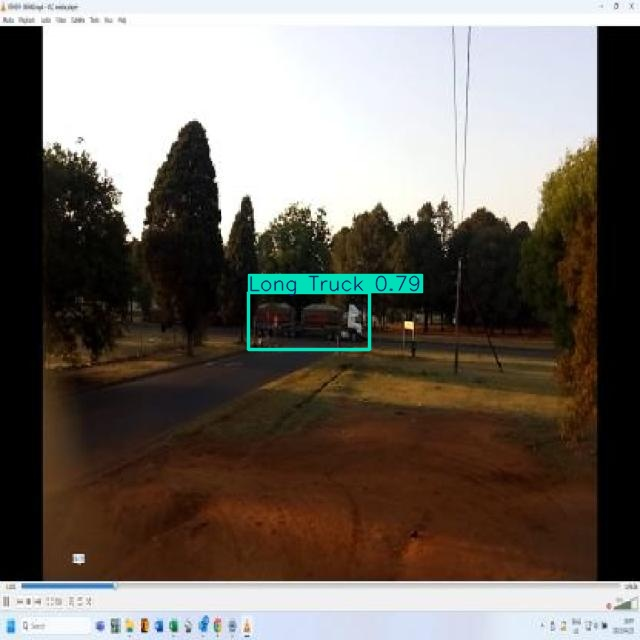

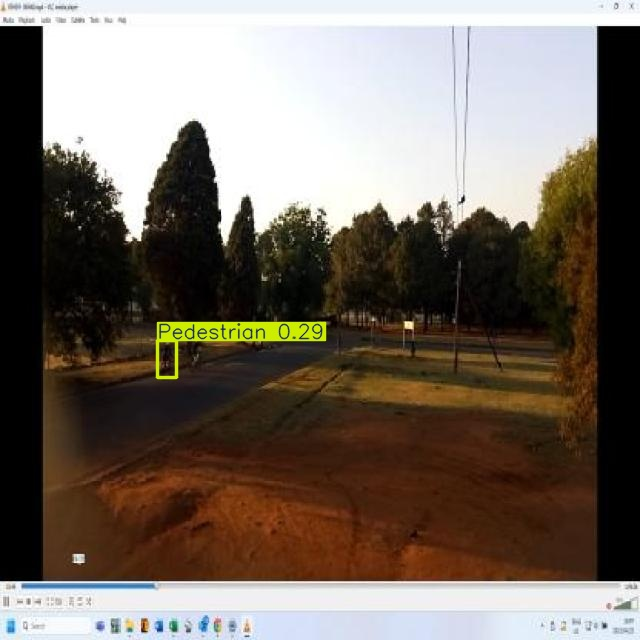

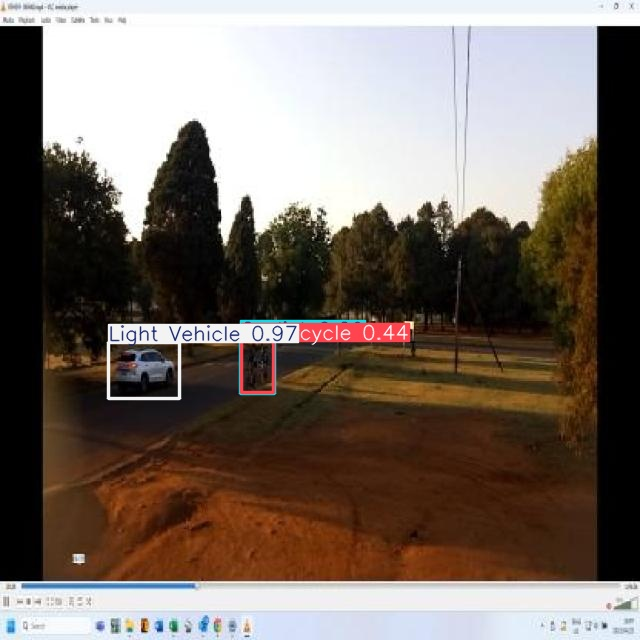

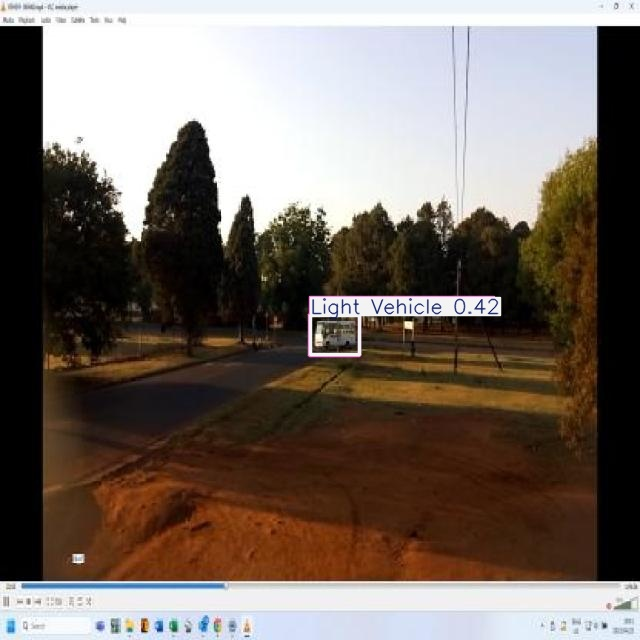

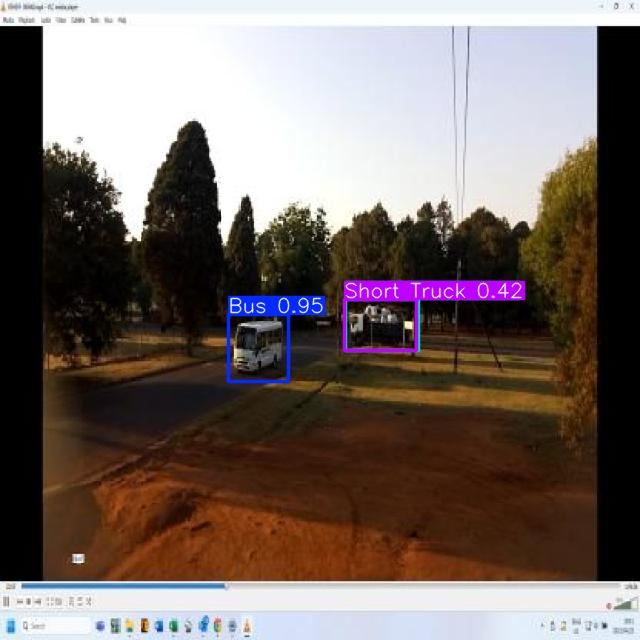

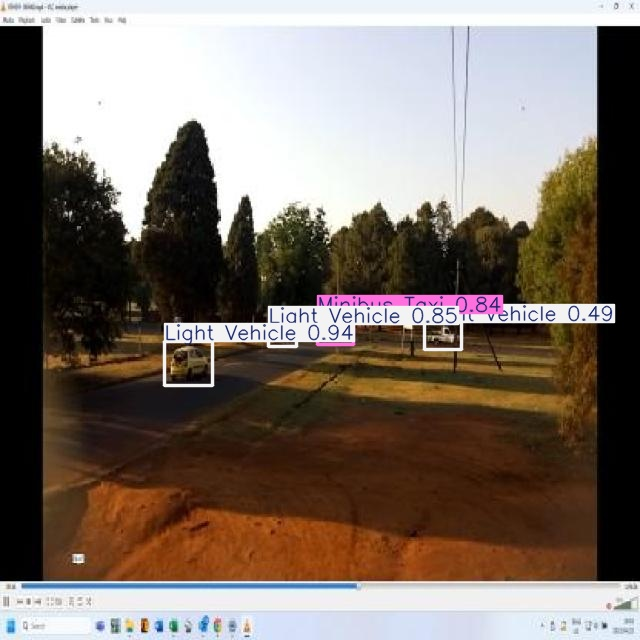

In [26]:
from IPython.display import Image, display
import os

path = "runs/detect/predict"
for img in os.listdir(path)[:6]:
    display(Image(filename=f"{path}/{img}"))

In [27]:
from ultralytics import YOLO

model = YOLO(r"D:\YOLO Model\best.pt")  # مسار الموديل

results = model.predict(
    source=r"D:\YOLO Model\test.mp4",   # 👈 حط مسار الفيديو
    save=True,                          # يحفظ الفيديو الناتج
    conf=0.25,                          # threshold
    device=0                            # GPU
)


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/705) D:\YOLO Model\test.mp4: 640x640 1 Cyclist, 17 Light Vehicles, 1 Minibus Taxi, 3 Motorcycles, 2 Pedestrians, 79.0ms
video 1/1 (frame 2/705) D:\YOLO Model\test.mp4: 640x640 1 Cyclist, 17 Light Vehicles, 1 Minibus Taxi, 3 Motorcycles, 1 Pedestrian, 63.0ms
video 1/1 (frame 3/705) D:\YOLO Model\test.mp4: 640x640 16 Light Vehicles, 1 Minibus Taxi, 2 Motorcycles, 1 Pedestrian, 62.0ms
video 1/1 (frame 4/705) D:\YOLO Model\test.mp4: 640x640 1

video 1/1 (frame 62/705) D:\YOLO Model\test.mp4: 640x640 17 Light Vehicles, 1 Minibus Taxi, 2 Motorcycles, 1 Pedestrian, 47.7ms
video 1/1 (frame 63/705) D:\YOLO Model\test.mp4: 640x640 16 Light Vehicles, 2 Minibus Taxis, 2 Motorcycles, 47.7ms
video 1/1 (frame 64/705) D:\YOLO Model\test.mp4: 640x640 16 Light Vehicles, 2 Minibus Taxis, 2 Motorcycles, 48.1ms
video 1/1 (frame 65/705) D:\YOLO Model\test.mp4: 640x640 16 Light Vehicles, 2 Minibus Taxis, 1 Motorcycle, 1 Pedestrian, 48.0ms
video 1/1 (frame 66/705) D:\YOLO Model\test.mp4: 640x640 1 Cyclist, 15 Light Vehicles, 2 Minibus Taxis, 1 Motorcycle, 47.4ms
video 1/1 (frame 67/705) D:\YOLO Model\test.mp4: 640x640 1 Cyclist, 16 Light Vehicles, 2 Minibus Taxis, 2 Motorcycles, 47.8ms
video 1/1 (frame 68/705) D:\YOLO Model\test.mp4: 640x640 15 Light Vehicles, 2 Minibus Taxis, 2 Motorcycles, 73.4ms
video 1/1 (frame 69/705) D:\YOLO Model\test.mp4: 640x640 16 Light Vehicles, 2 Motorcycles, 47.6ms
video 1/1 (frame 70/705) D:\YOLO Model\test.mp4: 6

video 1/1 (frame 127/705) D:\YOLO Model\test.mp4: 640x640 1 Cyclist, 15 Light Vehicles, 2 Minibus Taxis, 2 Motorcycles, 47.2ms
video 1/1 (frame 128/705) D:\YOLO Model\test.mp4: 640x640 2 Cyclists, 15 Light Vehicles, 2 Minibus Taxis, 2 Motorcycles, 47.6ms
video 1/1 (frame 129/705) D:\YOLO Model\test.mp4: 640x640 1 Cyclist, 16 Light Vehicles, 2 Minibus Taxis, 2 Motorcycles, 47.8ms
video 1/1 (frame 130/705) D:\YOLO Model\test.mp4: 640x640 14 Light Vehicles, 1 Minibus Taxi, 2 Motorcycles, 47.4ms
video 1/1 (frame 131/705) D:\YOLO Model\test.mp4: 640x640 1 Cyclist, 12 Light Vehicles, 1 Minibus Taxi, 2 Motorcycles, 47.4ms
video 1/1 (frame 132/705) D:\YOLO Model\test.mp4: 640x640 1 Cyclist, 12 Light Vehicles, 1 Minibus Taxi, 2 Motorcycles, 48.0ms
video 1/1 (frame 133/705) D:\YOLO Model\test.mp4: 640x640 2 Cyclists, 13 Light Vehicles, 2 Minibus Taxis, 2 Motorcycles, 48.0ms
video 1/1 (frame 134/705) D:\YOLO Model\test.mp4: 640x640 1 Cyclist, 17 Light Vehicles, 2 Minibus Taxis, 2 Motorcycles, 48.

video 1/1 (frame 200/705) D:\YOLO Model\test.mp4: 640x640 11 Light Vehicles, 1 Minibus Taxi, 1 Pedestrian, 27.0ms
video 1/1 (frame 201/705) D:\YOLO Model\test.mp4: 640x640 11 Light Vehicles, 2 Minibus Taxis, 1 Pedestrian, 23.3ms
video 1/1 (frame 202/705) D:\YOLO Model\test.mp4: 640x640 11 Light Vehicles, 2 Minibus Taxis, 1 Pedestrian, 21.6ms
video 1/1 (frame 203/705) D:\YOLO Model\test.mp4: 640x640 12 Light Vehicles, 1 Minibus Taxi, 1 Pedestrian, 23.5ms
video 1/1 (frame 204/705) D:\YOLO Model\test.mp4: 640x640 1 Bus, 11 Light Vehicles, 1 Minibus Taxi, 2 Pedestrians, 22.5ms
video 1/1 (frame 205/705) D:\YOLO Model\test.mp4: 640x640 1 Bus, 12 Light Vehicles, 1 Minibus Taxi, 2 Pedestrians, 22.2ms
video 1/1 (frame 206/705) D:\YOLO Model\test.mp4: 640x640 12 Light Vehicles, 1 Minibus Taxi, 2 Pedestrians, 23.7ms
video 1/1 (frame 207/705) D:\YOLO Model\test.mp4: 640x640 12 Light Vehicles, 1 Minibus Taxi, 2 Pedestrians, 25.0ms
video 1/1 (frame 208/705) D:\YOLO Model\test.mp4: 640x640 12 Light V

video 1/1 (frame 269/705) D:\YOLO Model\test.mp4: 640x640 1 Bus, 11 Light Vehicles, 2 Motorcycles, 44.0ms
video 1/1 (frame 270/705) D:\YOLO Model\test.mp4: 640x640 1 Bus, 12 Light Vehicles, 2 Motorcycles, 49.5ms
video 1/1 (frame 271/705) D:\YOLO Model\test.mp4: 640x640 12 Light Vehicles, 2 Motorcycles, 48.7ms
video 1/1 (frame 272/705) D:\YOLO Model\test.mp4: 640x640 13 Light Vehicles, 1 Minibus Taxi, 2 Motorcycles, 43.7ms
video 1/1 (frame 273/705) D:\YOLO Model\test.mp4: 640x640 11 Light Vehicles, 2 Motorcycles, 44.0ms
video 1/1 (frame 274/705) D:\YOLO Model\test.mp4: 640x640 13 Light Vehicles, 2 Motorcycles, 43.9ms
video 1/1 (frame 275/705) D:\YOLO Model\test.mp4: 640x640 13 Light Vehicles, 1 Minibus Taxi, 2 Motorcycles, 43.9ms
video 1/1 (frame 276/705) D:\YOLO Model\test.mp4: 640x640 12 Light Vehicles, 1 Minibus Taxi, 2 Motorcycles, 43.4ms
video 1/1 (frame 277/705) D:\YOLO Model\test.mp4: 640x640 10 Light Vehicles, 1 Minibus Taxi, 2 Motorcycles, 43.6ms
video 1/1 (frame 278/705) D:\YO

...

video 1/1 (frame 401/705) D:\YOLO Model\test.mp4: 640x640 14 Light Vehicles, 1 Minibus Taxi, 2 Motorcycles, 1 Pedestrian, 48.3ms
video 1/1 (frame 402/705) D:\YOLO Model\test.mp4: 640x640 14 Light Vehicles, 2 Minibus Taxis, 1 Motorcycle, 2 Pedestrians, 47.8ms
video 1/1 (frame 403/705) D:\YOLO Model\test.mp4: 640x640 12 Light Vehicles, 2 Minibus Taxis, 1 Motorcycle, 1 Pedestrian, 51.1ms
video 1/1 (frame 404/705) D:\YOLO Model\test.mp4: 640x640 13 Light Vehicles, 1 Minibus Taxi, 2 Motorcycles, 2 Pedestrians, 47.6ms
video 1/1 (frame 405/705) D:\YOLO Model\test.mp4: 640x640 14 Light Vehicles, 1 Minibus Taxi, 1 Motorcycle, 2 Pedestrians, 48.0ms
video 1/1 (frame 406/705) D:\YOLO Model\test.mp4: 640x640 14 Light Vehicles, 2 Minibus Taxis, 2 Pedestrians, 49.1ms
video 1/1 (frame 407/705) D:\YOLO Model\test.mp4: 640x640 15 Light Vehicles, 2 Minibus Taxis, 1 Motorcycle, 2 Pedestrians, 48.1ms
video 1/1 (frame 408/705) D:\YOLO Model\test.mp4: 640x640 15 Light Vehicles, 2 Minibus Taxis, 1 Motorcycle,

video 1/1 (frame 464/705) D:\YOLO Model\test.mp4: 640x640 2 Cyclists, 9 Light Vehicles, 4 Minibus Taxis, 3 Motorcycles, 1 Pedestrian, 48.1ms
video 1/1 (frame 465/705) D:\YOLO Model\test.mp4: 640x640 1 Cyclist, 9 Light Vehicles, 4 Minibus Taxis, 3 Motorcycles, 1 Pedestrian, 48.0ms
video 1/1 (frame 466/705) D:\YOLO Model\test.mp4: 640x640 9 Light Vehicles, 4 Minibus Taxis, 3 Motorcycles, 1 Pedestrian, 48.1ms
video 1/1 (frame 467/705) D:\YOLO Model\test.mp4: 640x640 10 Light Vehicles, 4 Minibus Taxis, 3 Motorcycles, 1 Pedestrian, 54.1ms
video 1/1 (frame 468/705) D:\YOLO Model\test.mp4: 640x640 1 Cyclist, 11 Light Vehicles, 4 Minibus Taxis, 3 Motorcycles, 1 Pedestrian, 48.0ms
video 1/1 (frame 469/705) D:\YOLO Model\test.mp4: 640x640 1 Cyclist, 9 Light Vehicles, 4 Minibus Taxis, 3 Motorcycles, 1 Pedestrian, 56.2ms
video 1/1 (frame 470/705) D:\YOLO Model\test.mp4: 640x640 11 Light Vehicles, 4 Minibus Taxis, 3 Motorcycles, 1 Pedestrian, 48.2ms
video 1/1 (frame 471/705) D:\YOLO Model\test.mp4:

video 1/1 (frame 525/705) D:\YOLO Model\test.mp4: 640x640 13 Light Vehicles, 4 Minibus Taxis, 1 Motorcycle, 1 Pedestrian, 55.1ms
video 1/1 (frame 526/705) D:\YOLO Model\test.mp4: 640x640 13 Light Vehicles, 3 Minibus Taxis, 1 Motorcycle, 1 Pedestrian, 47.0ms
video 1/1 (frame 527/705) D:\YOLO Model\test.mp4: 640x640 13 Light Vehicles, 3 Minibus Taxis, 1 Motorcycle, 2 Pedestrians, 47.5ms
video 1/1 (frame 528/705) D:\YOLO Model\test.mp4: 640x640 11 Light Vehicles, 3 Minibus Taxis, 1 Motorcycle, 2 Pedestrians, 52.1ms
video 1/1 (frame 529/705) D:\YOLO Model\test.mp4: 640x640 12 Light Vehicles, 3 Minibus Taxis, 1 Motorcycle, 2 Pedestrians, 47.7ms
video 1/1 (frame 530/705) D:\YOLO Model\test.mp4: 640x640 11 Light Vehicles, 4 Minibus Taxis, 1 Motorcycle, 2 Pedestrians, 48.1ms
video 1/1 (frame 531/705) D:\YOLO Model\test.mp4: 640x640 10 Light Vehicles, 2 Minibus Taxis, 1 Motorcycle, 2 Pedestrians, 51.8ms
video 1/1 (frame 532/705) D:\YOLO Model\test.mp4: 640x640 10 Light Vehicles, 3 Minibus Taxis

video 1/1 (frame 587/705) D:\YOLO Model\test.mp4: 640x640 1 Cyclist, 16 Light Vehicles, 2 Minibus Taxis, 1 Pedestrian, 48.3ms
video 1/1 (frame 588/705) D:\YOLO Model\test.mp4: 640x640 1 Cyclist, 17 Light Vehicles, 2 Minibus Taxis, 1 Pedestrian, 53.5ms
video 1/1 (frame 589/705) D:\YOLO Model\test.mp4: 640x640 1 Cyclist, 15 Light Vehicles, 2 Minibus Taxis, 1 Pedestrian, 53.1ms
video 1/1 (frame 590/705) D:\YOLO Model\test.mp4: 640x640 15 Light Vehicles, 3 Minibus Taxis, 1 Pedestrian, 47.7ms
video 1/1 (frame 591/705) D:\YOLO Model\test.mp4: 640x640 1 Cyclist, 16 Light Vehicles, 3 Minibus Taxis, 2 Pedestrians, 51.0ms
video 1/1 (frame 592/705) D:\YOLO Model\test.mp4: 640x640 14 Light Vehicles, 3 Minibus Taxis, 3 Pedestrians, 48.0ms
video 1/1 (frame 593/705) D:\YOLO Model\test.mp4: 640x640 14 Light Vehicles, 3 Minibus Taxis, 3 Pedestrians, 47.8ms
video 1/1 (frame 594/705) D:\YOLO Model\test.mp4: 640x640 14 Light Vehicles, 3 Minibus Taxis, 3 Pedestrians, 47.9ms
video 1/1 (frame 595/705) D:\YOL

video 1/1 (frame 658/705) D:\YOLO Model\test.mp4: 640x640 14 Light Vehicles, 1 Minibus Taxi, 1 Pedestrian, 48.2ms
video 1/1 (frame 659/705) D:\YOLO Model\test.mp4: 640x640 13 Light Vehicles, 1 Minibus Taxi, 1 Pedestrian, 48.1ms
video 1/1 (frame 660/705) D:\YOLO Model\test.mp4: 640x640 13 Light Vehicles, 1 Minibus Taxi, 2 Pedestrians, 47.2ms
video 1/1 (frame 661/705) D:\YOLO Model\test.mp4: 640x640 14 Light Vehicles, 1 Minibus Taxi, 1 Pedestrian, 47.3ms
video 1/1 (frame 662/705) D:\YOLO Model\test.mp4: 640x640 13 Light Vehicles, 1 Minibus Taxi, 1 Pedestrian, 47.7ms
video 1/1 (frame 663/705) D:\YOLO Model\test.mp4: 640x640 13 Light Vehicles, 2 Minibus Taxis, 1 Pedestrian, 52.1ms
video 1/1 (frame 664/705) D:\YOLO Model\test.mp4: 640x640 13 Light Vehicles, 1 Minibus Taxi, 1 Pedestrian, 47.7ms
video 1/1 (frame 665/705) D:\YOLO Model\test.mp4: 640x640 15 Light Vehicles, 1 Minibus Taxi, 1 Pedestrian, 47.4ms
video 1/1 (frame 666/705) D:\YOLO Model\test.mp4: 640x640 12 Light Vehicles, 1 Minibus

In [32]:
import os

os.startfile("C:/Users/ahmed/runs/detect/predict-3/test.avi")